## Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Obtener datos de archivo

In [3]:
df = pd.read_excel('../data/stats_test_2.xlsx')
df.head()

,TIEMPO (seg),PUNTAJE (pts),EXITO (%),"GRAVEDAD (-15, 0)","PODER VIENTO (0, 20)"
0,5.89,-4.24,33.33,-5.0,0.4
1,7.00,-500.29,33.33,-3.0,0.4
2,29.19,-924.64,0.00,-1.0,0.4
3,7.99,-1526.27,0.00,0.5,0.4
4,5.86,-467.75,0.00,-5.0,0.4


## Limpiar datos

In [4]:
# Clean columns by removing non-standard minus signs, replacing commas with dots, and converting to float
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace('−', '-').str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any rows that couldn't be parsed properly (if any)
df = df.dropna()

# Rename columns slightly for cleaner axis labels
df.columns = [col.strip() for col in df.columns]
df.columns

Index(['TIEMPO (seg)', 'PUNTAJE (pts)', 'EXITO (%)', 'GRAVEDAD (-15, 0)',
       'PODER VIENTO (0, 20)'],
      dtype='object')

## Generación de gráficos

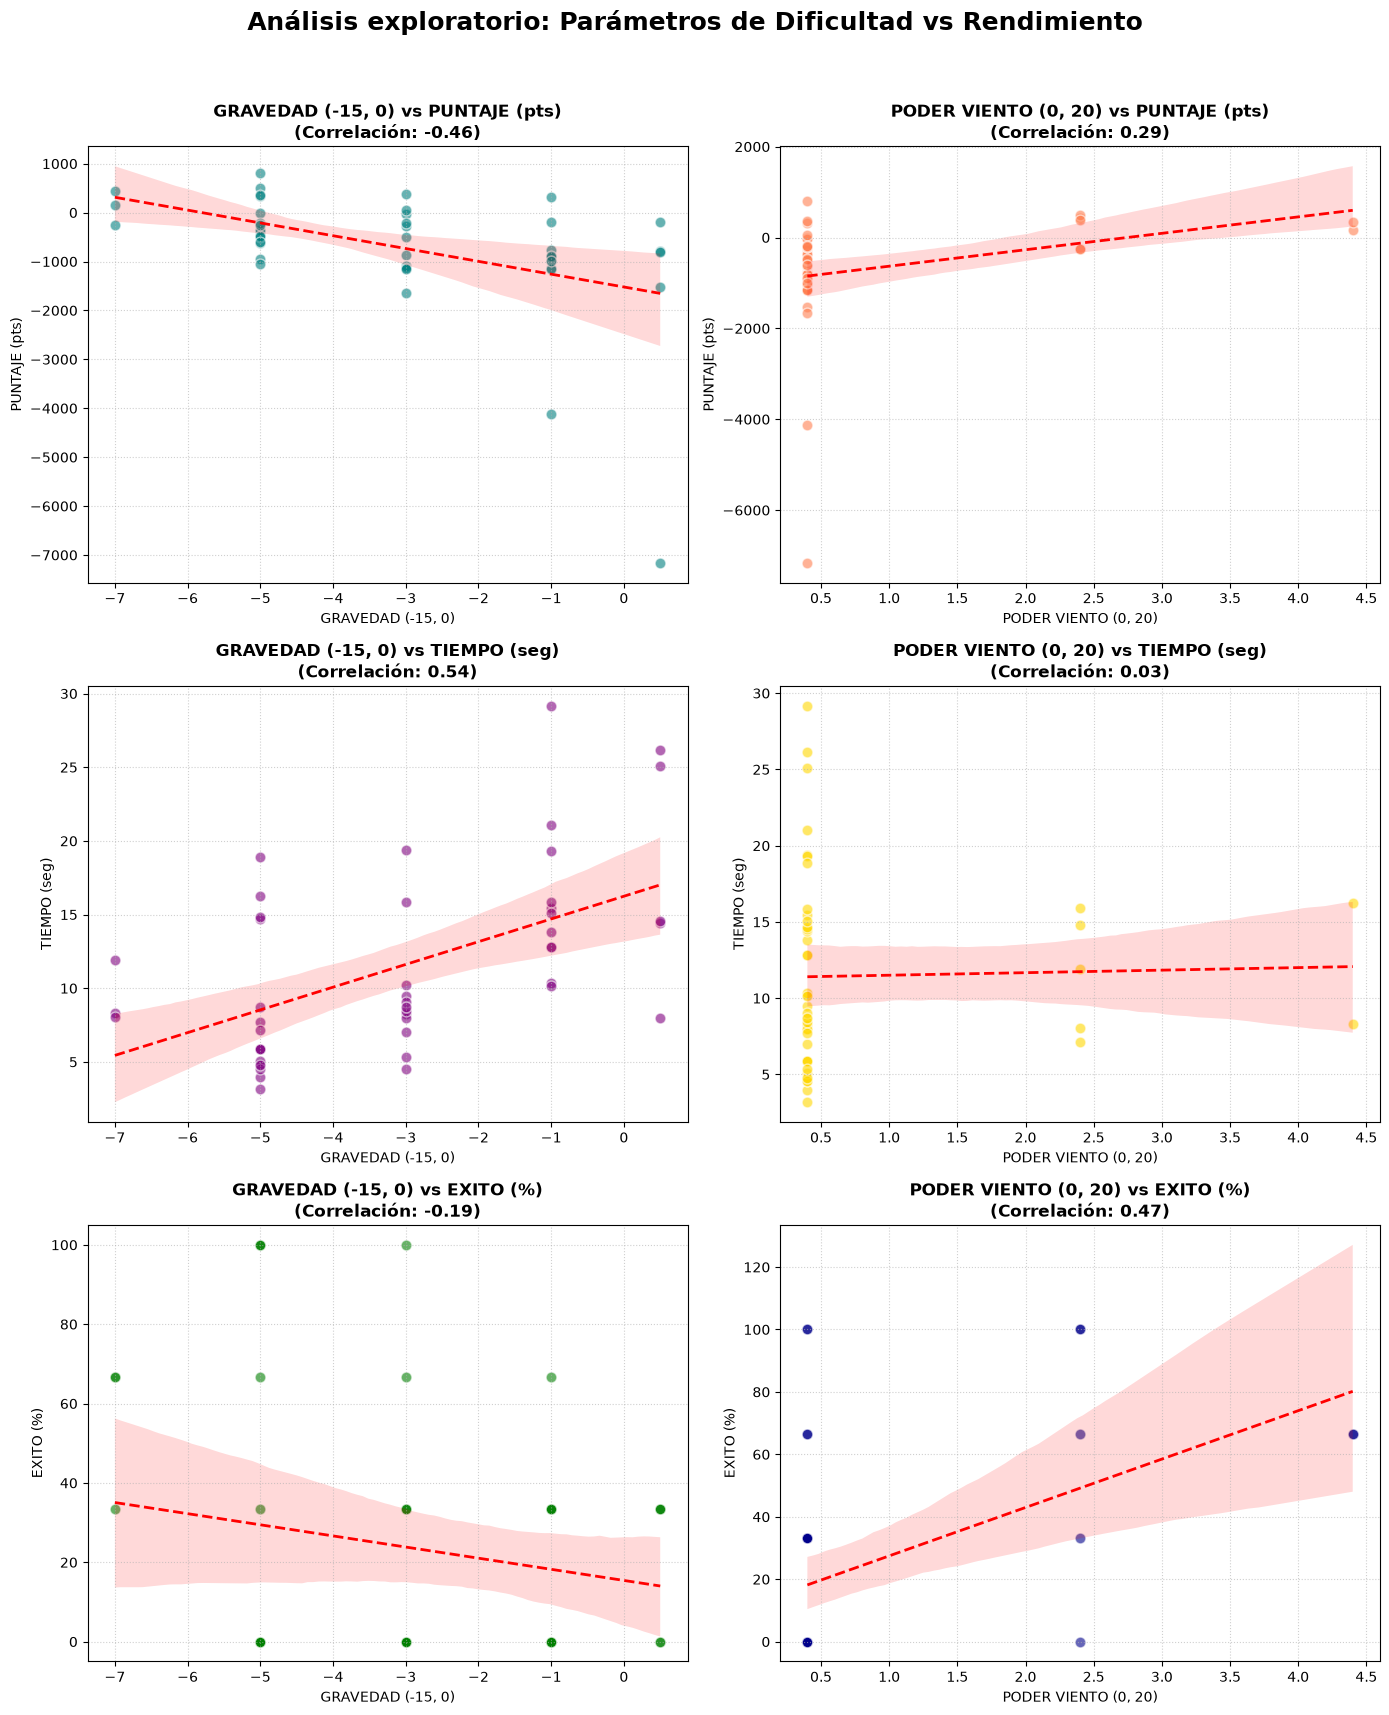

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle('Análisis exploratorio: Parámetros de Dificultad vs Rendimiento', fontsize=18, fontweight='bold', y=0.95)

# Define our Independent (X) and Dependent (Y) variables based on your request
relationships = [
    ('GRAVEDAD (-15, 0)', 'PUNTAJE (pts)', axes[0, 0], 'teal'),
    ('PODER VIENTO (0, 20)', 'PUNTAJE (pts)', axes[0, 1], 'coral'),
    ('GRAVEDAD (-15, 0)', 'TIEMPO (seg)', axes[1, 0], 'purple'),
    ('PODER VIENTO (0, 20)', 'TIEMPO (seg)', axes[1, 1], 'gold'),
    ('GRAVEDAD (-15, 0)', 'EXITO (%)', axes[2, 0], 'green'),
    ('PODER VIENTO (0, 20)', 'EXITO (%)', axes[2, 1], 'darkblue')
]

for x_col, y_col, ax, color in relationships:
    # Use a scatter plot with a trendline (regplot) to show the "progress" / relationship
    # ax.scatter(df[x_col], df[y_col])
    sns.regplot(
        data=df, 
        x=x_col, 
        y=y_col, 
        ax=ax, 
        color=color, 
        scatter_kws={'alpha':0.6, 'edgecolor':'w', 's':60},
        line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'}
    )
    
    # Calculate Pearson correlation to display on the plot
    correlation = df[x_col].corr(df[y_col])
    
    # Formatting
    ax.set_title(f'{x_col} vs {y_col}\n(Correlación: {correlation:.2f})', fontsize=12, fontweight='bold')
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel(y_col, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

# Adjust layout so labels don't overlap
plt.tight_layout(rect=[0, 0, 1, 0.93])

# 6. Optional: Print a quick statistical summary matrix
# print("--- Correlation Matrix ---")
# print(df.corr())

# Display the dashboard
plt.show()

<Axes: >

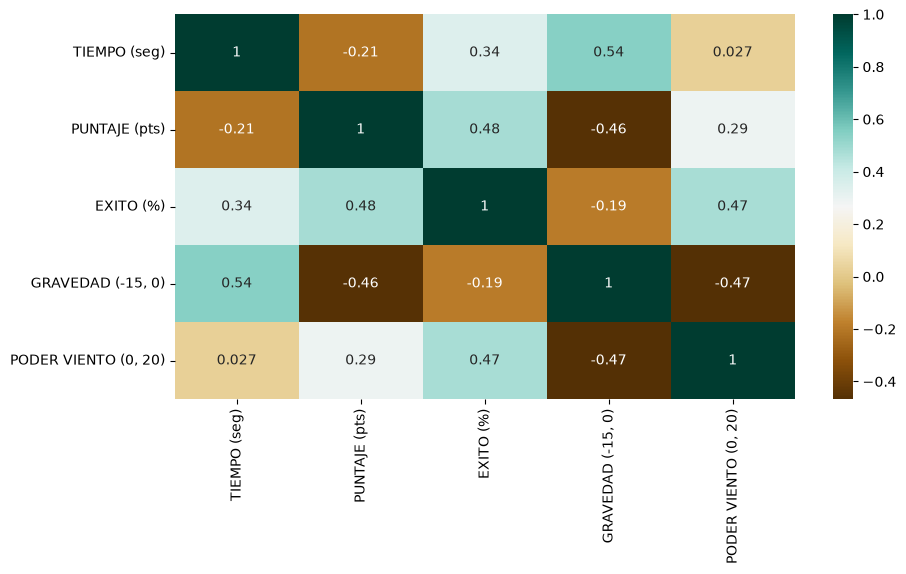

In [6]:
plt.figure(figsize=(10,5))
c= df.corr()
sns.heatmap(c,cmap="BrBG",annot=True)

## Histograma para cada nivel segun valor de gravedad

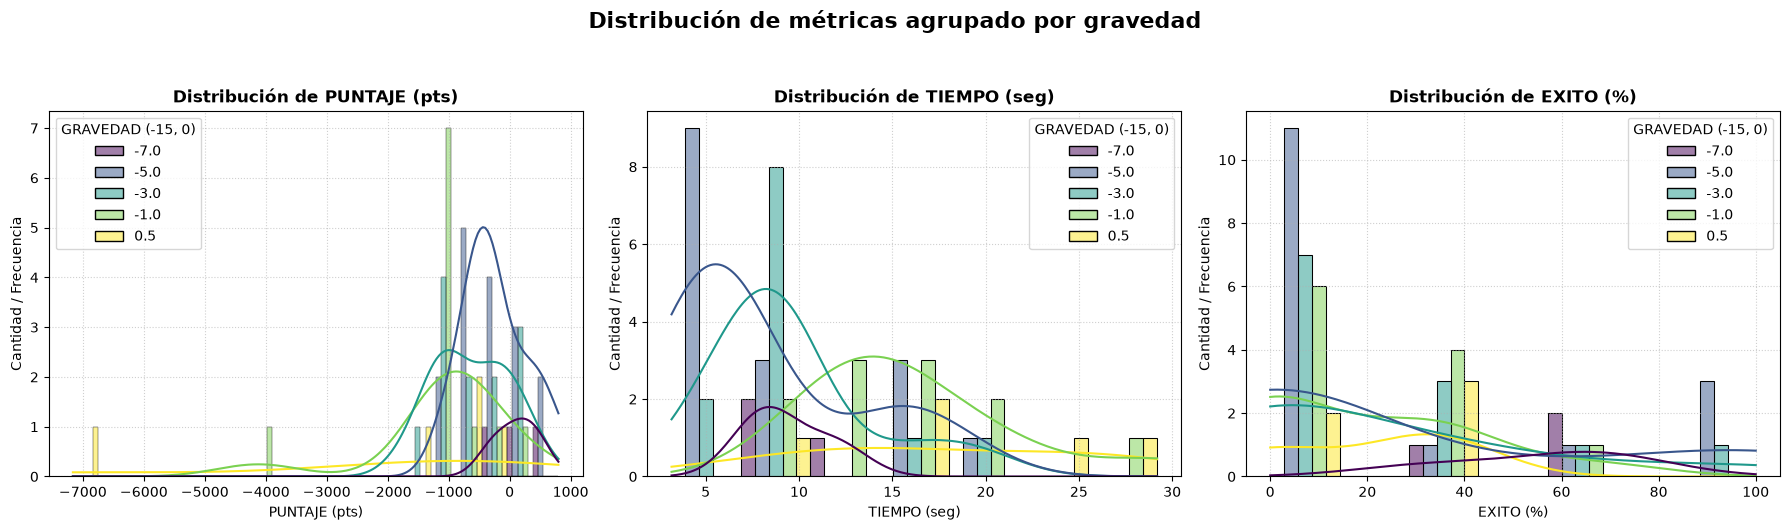

--- Resumen de estadísticas agrupado por gravedad ---

Resumen de PUNTAJE (pts):
                   count         mean          std      min     max
GRAVEDAD (-15, 0)                                                  
-7.0                 3.0   109.526667   348.974716  -259.69  433.93
-5.0                16.0  -245.041875   519.128726 -1053.81  799.78
-3.0                12.0  -630.719167   616.780141 -1650.51  377.66
-1.0                11.0 -1065.966364  1105.114010 -4121.83  315.41
 0.5                 5.0 -2095.872000  2872.237512 -7163.20 -185.61

Resumen de TIEMPO (seg):
                   count       mean       std    min    max
GRAVEDAD (-15, 0)                                          
-7.0                 3.0   9.433333  2.167033   8.04  11.93
-5.0                16.0   8.266875  4.977031   3.17  18.88
-3.0                12.0   9.523333  4.185019   4.54  19.37
-1.0                11.0  15.994545  5.501340  10.16  29.19
 0.5                 5.0  17.648000  7.768315   7.99  26.

In [15]:
# 2. Define Variables
gravity_col = 'GRAVEDAD (-15, 0)'
metrics = ['PUNTAJE (pts)', 'TIEMPO (seg)', 'EXITO (%)']

# Get unique gravity values to dynamically adjust colors/labels
unique_gravities = sorted(df[gravity_col].unique())

# 3. Set up the plotting grid (1 row, 3 columns for the 3 metrics)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de métricas agrupado por gravedad', fontsize=16, fontweight='bold', y=1.05)

# 4. Generate Histograms
for i, metric in enumerate(metrics):
    # We use seaborn's histplot with 'hue' to automatically group and color by gravity
    sns.histplot(
        data=df,
        x=metric,
        hue=gravity_col,
        palette='viridis',  # Clean color palette for distinct groups
        multiple='dodge',   # Overlaps the bars transparently; change to 'dodge' if you prefer side-by-side
        kde=True,           # Adds a kernel density estimation line to see the smooth distribution shape
        ax=axes[i],
        alpha=0.5
    )
    # Formatting each subplot
    axes[i].set_title(f'Distribución de {metric}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(metric, fontsize=10)
    axes[i].set_ylabel('Cantidad / Frecuencia', fontsize=10)
    axes[i].grid(True, linestyle=':', alpha=0.6)

# Adjust layout to fit titles cleanly
plt.tight_layout()
plt.show()

# 5. Optional: Print descriptive statistics grouped by gravity
print("--- Resumen de estadísticas agrupado por gravedad ---")
for metric in metrics:
    print(f"\nResumen de {metric}:")
    print(df.groupby(gravity_col)[metric].describe()[['count', 'mean', 'std', 'min', 'max']])

## Histograma para cada nivel segun valor de poder del viento

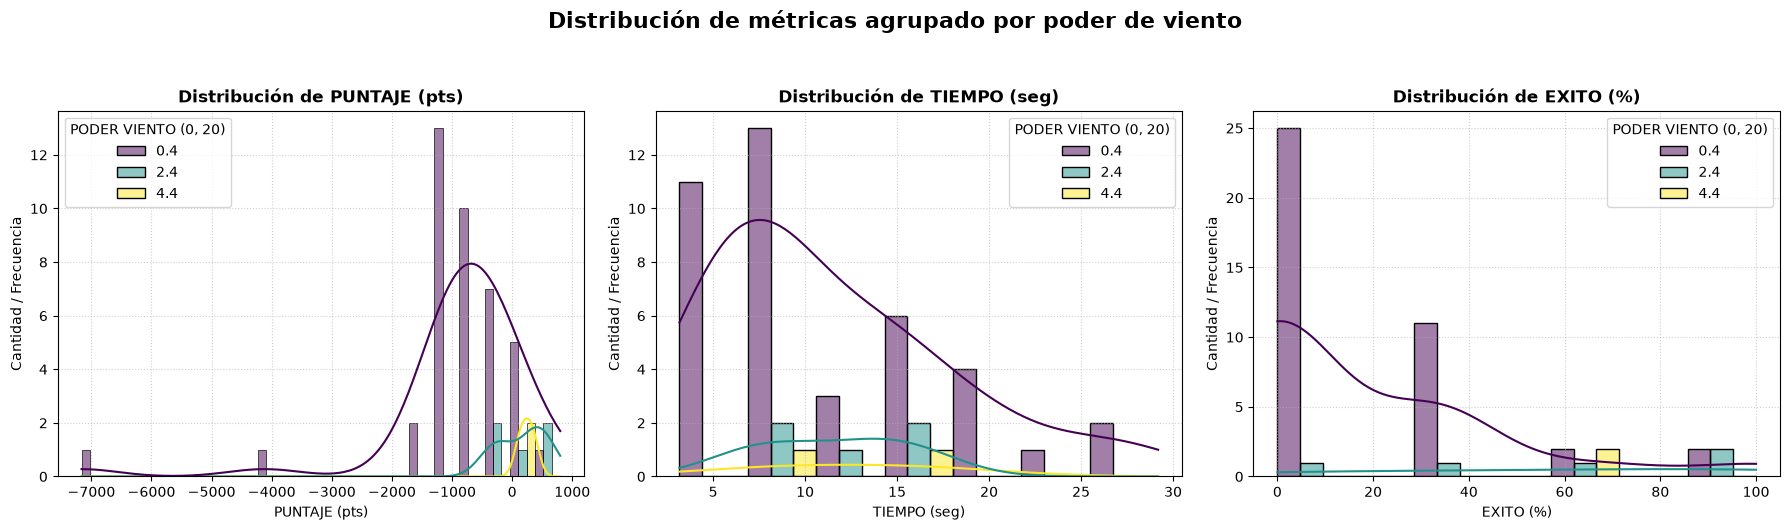

In [23]:
# 2. Define Variables
wind_power_col = 'PODER VIENTO (0, 20)'
metrics = ['PUNTAJE (pts)', 'TIEMPO (seg)', 'EXITO (%)']

# Get unique wind_power values to dynamically adjust colors/labels
unique_gravities = sorted(df[wind_power_col].unique())

# 3. Set up the plotting grid (1 row, 3 columns for the 3 metrics)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de métricas agrupado por poder de viento', fontsize=16, fontweight='bold', y=1.05)

# 4. Generate Histograms
for i, metric in enumerate(metrics):
    # We use seaborn's histplot with 'hue' to automatically group and color by wind_power
    sns.histplot(
        data=df,
        x=metric,
        hue=wind_power_col,
        palette='viridis',  # Clean color palette for distinct groups
        multiple='dodge',   # Overlaps the bars transparently; change to 'dodge' if you prefer side-by-side
        kde=True,           # Adds a kernel density estimation line to see the smooth distribution shape
        ax=axes[i],
        alpha=0.5
    )
    # Formatting each subplot
    axes[i].set_title(f'Distribución de {metric}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(metric, fontsize=10)
    axes[i].set_ylabel('Cantidad / Frecuencia', fontsize=10)
    axes[i].grid(True, linestyle=':', alpha=0.6)

# Adjust layout to fit titles cleanly
plt.tight_layout()
plt.show()

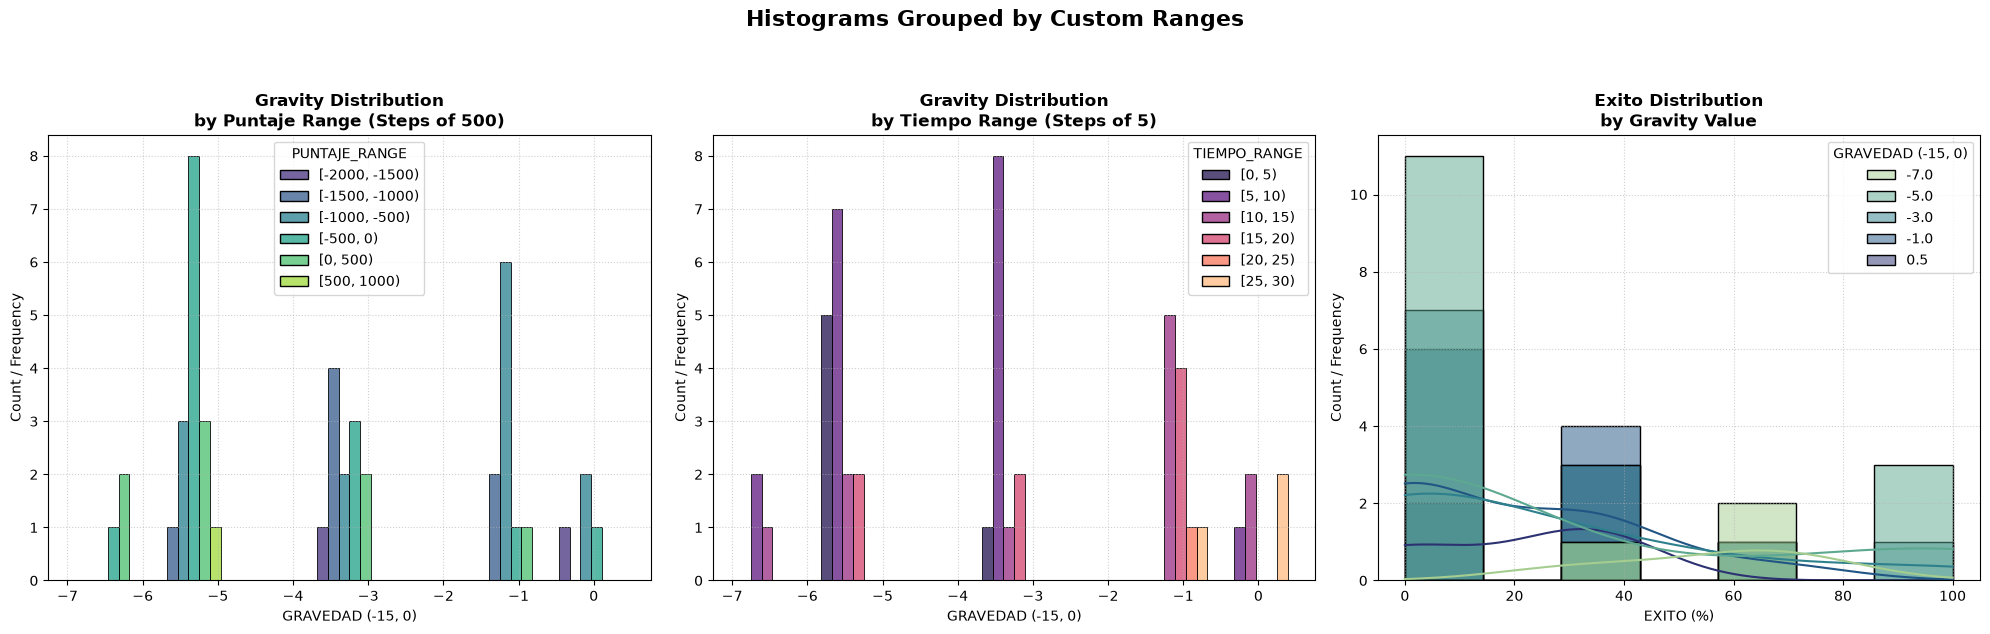

--- Resumen de estadísticas agrupado por gravedad ---

Resumen de PUNTAJE (pts):
                   count         mean          std      min     max
GRAVEDAD (-15, 0)                                                  
-7.0                 3.0   109.526667   348.974716  -259.69  433.93
-5.0                16.0  -245.041875   519.128726 -1053.81  799.78
-3.0                12.0  -630.719167   616.780141 -1650.51  377.66
-1.0                11.0 -1065.966364  1105.114010 -4121.83  315.41
 0.5                 5.0 -2095.872000  2872.237512 -7163.20 -185.61

Resumen de TIEMPO (seg):
                   count       mean       std    min    max
GRAVEDAD (-15, 0)                                          
-7.0                 3.0   9.433333  2.167033   8.04  11.93
-5.0                16.0   8.266875  4.977031   3.17  18.88
-3.0                12.0   9.523333  4.185019   4.54  19.37
-1.0                11.0  15.994545  5.501340  10.16  29.19
 0.5                 5.0  17.648000  7.768315   7.99  26.

Text(0.5, 1.05, 'Histograms Grouped by Custom Ranges (Gravity)')

In [24]:
# --- 2. Create the custom Hue Ranges ---

# Bin PUNTAJE in steps of 500 (from 0 to max value + 500)
max_puntaje = int(df['PUNTAJE (pts)'].max()) + 500
puntaje_bins = list(range(-2000, max_puntaje, 500))
df['PUNTAJE_RANGE'] = pd.cut(df['PUNTAJE (pts)'], bins=puntaje_bins, right=False)

# Bin TIEMPO in steps of 5 (from 0 to max value + 5)
max_tiempo = int(df['TIEMPO (seg)'].max()) + 5
tiempo_bins = list(range(0, max_tiempo, 5))
df['TIEMPO_RANGE'] = pd.cut(df['TIEMPO (seg)'], bins=tiempo_bins, right=False)

# --- 3. Set up the plotting grid ---
# We have 3 unique combinations requested, so we'll make a 1x3 dashboard
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Histograms Grouped by Custom Ranges', fontsize=16, fontweight='bold', y=1.05)

# Plot 1: Gravity on X, Hue grouped by PUNTAJE (Ranges of 500)
sns.histplot(
    data=df,
    x='GRAVEDAD (-15, 0)',
    hue='PUNTAJE_RANGE',
    palette='viridis',
    multiple='dodge',  # 'dodge' places bars side-by-side for cleaner categorical comparisons
    ax=axes[0],
    shrink=0.8
)
axes[0].set_title('Gravity Distribution\nby Puntaje Range (Steps of 500)', fontsize=12, fontweight='bold')


# Plot 2: Gravity on X, Hue grouped by TIEMPO (Ranges of 5)
sns.histplot(
    data=df,
    x='GRAVEDAD (-15, 0)',
    hue='TIEMPO_RANGE',
    palette='magma',
    multiple='dodge',
    ax=axes[1],
    shrink=0.8
)
axes[1].set_title('Gravity Distribution\nby Tiempo Range (Steps of 5)', fontsize=12, fontweight='bold')


# Plot 3: Success on X, Hue grouped by Gravity (For reference/completion)
sns.histplot(
    data=df,
    x='EXITO (%)',
    hue='GRAVEDAD (-15, 0)',
    palette='crest',
    multiple='layer',  # Layer works beautifully for overlapping standard continuous distributions
    kde=True,
    ax=axes[2]
)
axes[2].set_title('Exito Distribution\nby Gravity Value', fontsize=12, fontweight='bold')


# Formatting tweaks
for ax in axes:
    ax.set_ylabel('Count / Frequency', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
# 5. Optional: Print descriptive statistics grouped by gravity
print("--- Resumen de estadísticas agrupado por gravedad ---")
for metric in metrics:
    print(f"\nResumen de {metric}:")
    print(df.groupby(gravity_col)[metric].describe()[['count', 'mean', 'std', 'min', 'max']])
fig.suptitle('Histograms Grouped by Custom Ranges (Gravity)', fontsize=16, fontweight='bold', y=1.05)

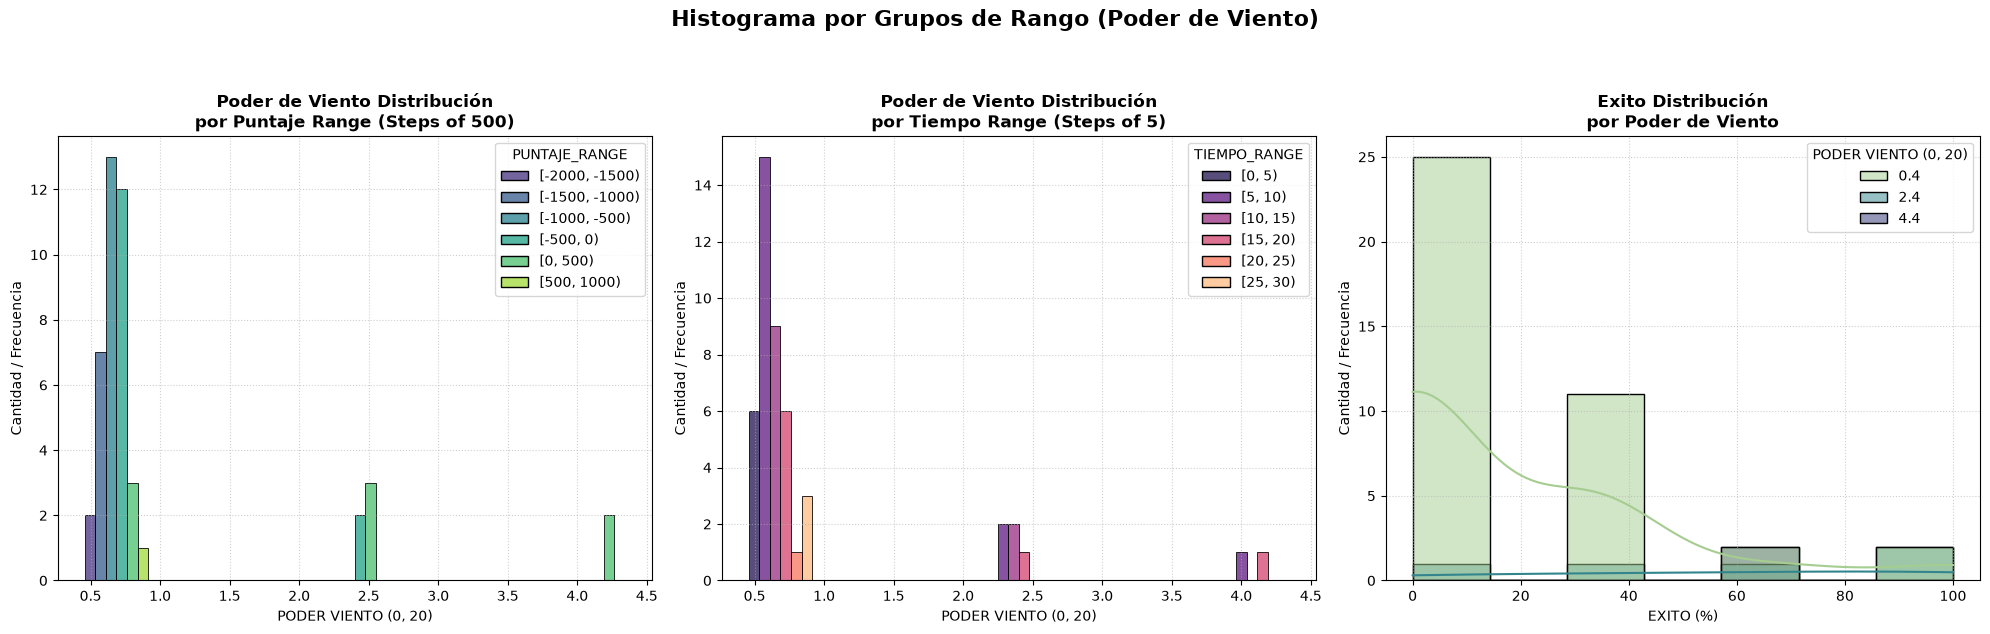

In [25]:
# --- 3. Set up the plotting grid ---
# We have 3 unique combinations requested, so we'll make a 1x3 dashboard
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Histograma por Grupos de Rango (Poder de Viento)', fontsize=16, fontweight='bold', y=1.05)


# Plot 1: Gravity on X, Hue grouped by PUNTAJE (Ranges of 500)
sns.histplot(
    data=df,
    x='PODER VIENTO (0, 20)',
    hue='PUNTAJE_RANGE',
    palette='viridis',
    multiple='dodge',  # 'dodge' places bars side-by-side for cleaner categorical comparisons
    ax=axes[0],
    shrink=0.8
)
axes[0].set_title('Poder de Viento Distribución\npor Puntaje Range (Steps of 500)', fontsize=12, fontweight='bold')


# Plot 2: Gravity on X, Hue grouped by TIEMPO (Ranges of 5)
sns.histplot(
    data=df,
    x='PODER VIENTO (0, 20)',
    hue='TIEMPO_RANGE',
    palette='magma',
    multiple='dodge',
    ax=axes[1],
    shrink=0.8
)
axes[1].set_title('Poder de Viento Distribución\npor Tiempo Range (Steps of 5)', fontsize=12, fontweight='bold')


# Plot 3: Success on X, Hue grouped by Gravity (For reference/completion)
sns.histplot(
    data=df,
    x='EXITO (%)',
    hue='PODER VIENTO (0, 20)',
    palette='crest',
    multiple='layer',  # Layer works beautifully for overlapping standard continuous distributions
    kde=True,
    ax=axes[2]
)
axes[2].set_title('Exito Distribución\npor Poder de Viento', fontsize=12, fontweight='bold')

# Formatting tweaks
for ax in axes:
    ax.set_ylabel('Cantidad / Frecuencia', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()